In [2]:
from HPC.Upload.pyfiles.classes import *
from random import choices
import cirq
import itertools
import textwrap


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Bitstream Vera Sans",
    "font.sans-serif": "Helvetica",
})

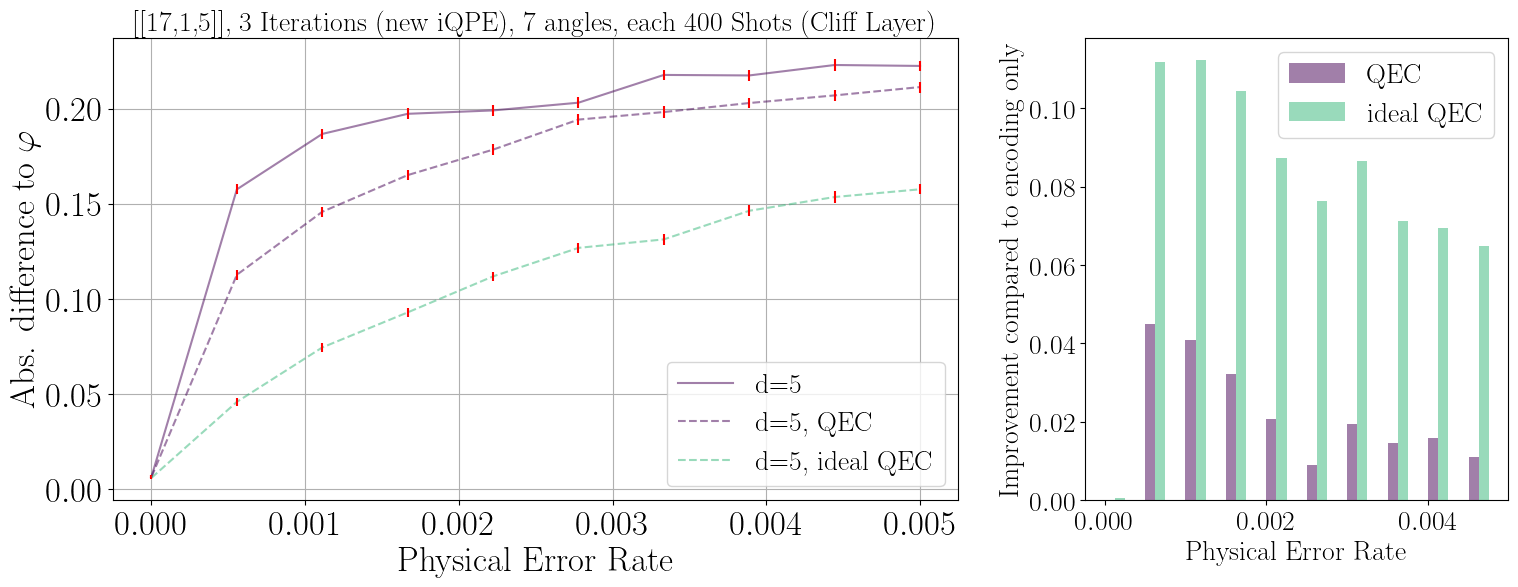

In [17]:
# [[17,1,5]] code, ramsey, 3 iterations, standard QEC via lookup table
shots = 400

p1, y1, y_qec1, err1, err_qec1 = np.loadtxt("HPC/text/bigsteane.txt", delimiter = ",")
p2, y2, y_qec2, err2, err_qec2 = np.loadtxt("HPC/text/bigsteane_lotqec.txt", delimiter = ",")
p3, y3, y_qec3, err3, err_qec3 = np.loadtxt("HPC/text/bigsteane_ftqec_lots.txt", delimiter = ",")
p4, y4, y_qec4, err4, err_qec4 = np.loadtxt("HPC/text/bigsteane_ftqec.txt", delimiter = ",")
p5, y5, y_qec5, err5, err_qec5 = np.loadtxt("HPC/text/bigsteane_idealqec_lots.txt", delimiter = ",")

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(18,6), gridspec_kw={"width_ratios": [2, 1]})

# try:
colors = plt.cm.viridis(np.linspace(0, 1, 7))
# except TypeError:
#     pass

ax1.plot(p1,y1, label="d=5", marker = "", linestyle = "-", markersize = 20, alpha = 0.5, color = colors[0])
ax1.errorbar(p1, y1, yerr=err1, ecolor="red", linestyle="")

ax1.plot(p1, y_qec1, label="d=5, QEC", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[0])
ax1.errorbar(p1, y_qec1, yerr=err_qec1, ecolor="red", linestyle="")

# ax1.plot(p2, y_qec2, label="d=5, more QEC", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[2])
# ax1.errorbar(p2, y_qec2, yerr=err_qec2, ecolor="red", linestyle="")

# ax1.plot(p3, y_qec3, label="d=5, 2-FTEC lots", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[4])
# ax1.errorbar(p3, y_qec3, yerr=err_qec3, ecolor="red", linestyle="")

# ax1.plot(p4, y_qec4, label="d=5, 2-FTEC", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[5])
# ax1.errorbar(p4, y_qec4, yerr=err_qec4, ecolor="red", linestyle="")

ax1.plot(p5, y_qec5, label="d=5, ideal QEC", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[4])
ax1.errorbar(p5, y_qec5, yerr=err_qec5, ecolor="red", linestyle="")


ax1.set_title(r"[[17,1,5]], 3 Iterations (new iQPE), 7 angles, each {} Shots (Cliff Layer)".format(int(shots)), fontsize=20)
ax1.set_xlabel("Physical Error Rate", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
ax1.legend(fontsize=20)
############################################################################################################################
x_hist = np.asarray(p1)

qec_hist = -(np.asarray(y_qec1) - np.asarray(y1))
more_qec_hist = -(np.asarray(y_qec2) - np.asarray(y1))
ftqec_hist = -(np.asarray(y_qec4) - np.asarray(y1))
ftqec_lots_hist = -(np.asarray(y_qec3) - np.asarray(y1))
idealqec_lots_hist = -(np.asarray(y_qec5) - np.asarray(y1))

# Use the same bin edges for all histograms
bins = np.histogram_bin_edges(x_hist, bins=10)
bin_width = bins[1] - bins[0]

# Calculate weighted histogram values
qec_counts, _ = np.histogram(x_hist, bins=bins, weights=qec_hist)
more_qec_counts, _ = np.histogram(x_hist, bins=bins, weights=more_qec_hist)
ftqec_counts, _ = np.histogram(x_hist, bins=bins, weights=ftqec_hist)
ftqec_lots_counts, _ = np.histogram(x_hist, bins=bins, weights=ftqec_lots_hist)
idealqec_lots_counts, _ = np.histogram(x_hist, bins=bins, weights=idealqec_lots_hist)

# Four bars side-by-side within each bin
bar_width = bin_width / 4
x = bins[:-1]

ax2.bar(
    x,
    qec_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[0],
    label="QEC"
)

# ax2.bar(
#     x + bar_width,
#     more_qec_counts,
#     width=bar_width,
#     align="edge",
#     alpha=0.5,
#     color=colors[2],
#     label="QEC (lots)"
# )

# ax2.bar(
#     x + 2 * bar_width,
#     ftqec_counts,
#     width=bar_width,
#     align="edge",
#     alpha=0.5,
#     color=colors[4],
#     label="2-FTEC"
# )

# ax2.bar(
#     x + 3 * bar_width,
#     ftqec_lots_counts,
#     width=bar_width,
#     align="edge",
#     alpha=0.5,
#     color=colors[5],
#     label="2-FTEC (lots)"
# )

ax2.bar(
    x +  bar_width,
    idealqec_lots_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[4],
    label="ideal QEC"
)


ax2.legend(fontsize=20)

ax2.tick_params(axis='both', which='major', labelsize=20)
ax2.set_xlabel("Physical Error Rate", fontsize=20)
ax2.set_ylabel(r"Improvement compared to encoding only", fontsize=20)

############################################################################################################################
#plt.tight_layout()
# plt.savefig("14.png", bbox_inches="tight" ,dpi=200)
plt.show()

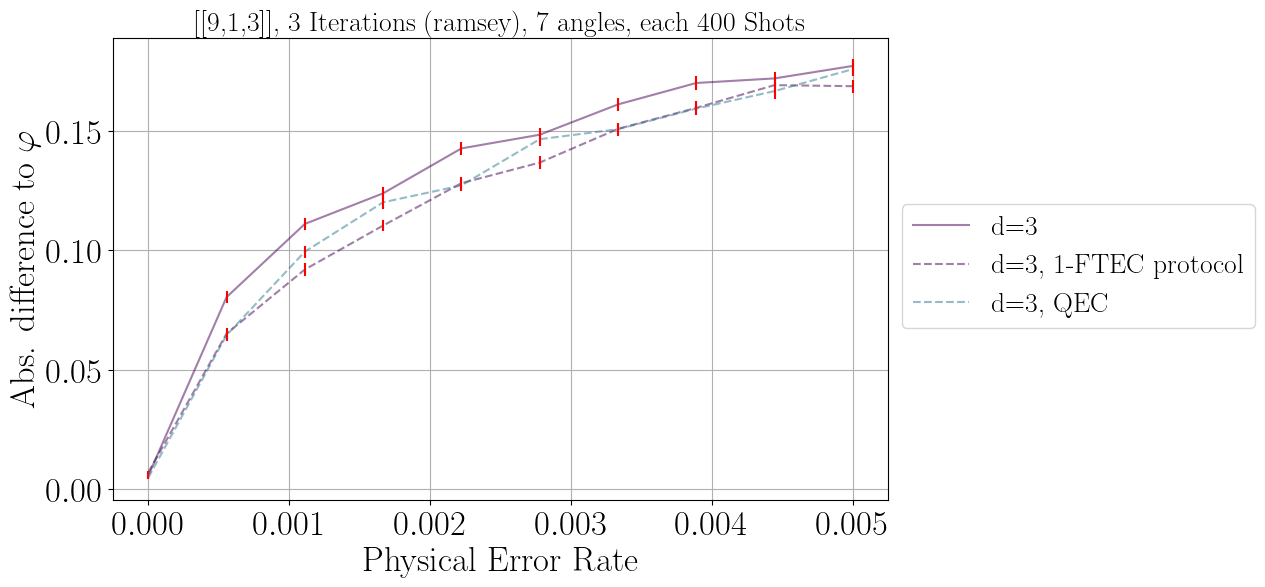

In [7]:
shots = 400

p1, y1, y_qec1, err1, err_qec1 = np.loadtxt("HPC/text/rotsurf_protocol.txt", delimiter = ",")
p2, y2, y_qec2, err2, err_qec2 = np.loadtxt("HPC/text/rotsurf_qec.txt", delimiter = ",")

fig, ax1 = plt.subplots(figsize=(10,6))

# try:
colors = plt.cm.viridis(np.linspace(0, 1, 6))
# except TypeError:
#     pass

ax1.plot(p1,y1, label="d=3", marker = "", linestyle = "-", markersize = 20, alpha = 0.5, color = colors[0])
ax1.errorbar(p1, y1, yerr=err1, ecolor="red", linestyle="")

ax1.plot(p1, y_qec1, label="d=3, 1-FTEC protocol", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[0])
ax1.errorbar(p1, y_qec1, yerr=err_qec1, ecolor="red", linestyle="")

ax1.plot(p2, y_qec2, label="d=3, QEC", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[2])
ax1.errorbar(p2, y_qec2, yerr=err_qec2, ecolor="red", linestyle="")


ax1.set_title(r"[[9,1,3]], 3 Iterations (ramsey), 7 angles, each {} Shots".format(int(shots)), fontsize=20)
ax1.set_xlabel("Physical Error Rate", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)


#plt.tight_layout()
# plt.savefig("14.png", bbox_inches="tight" ,dpi=200)
plt.show()

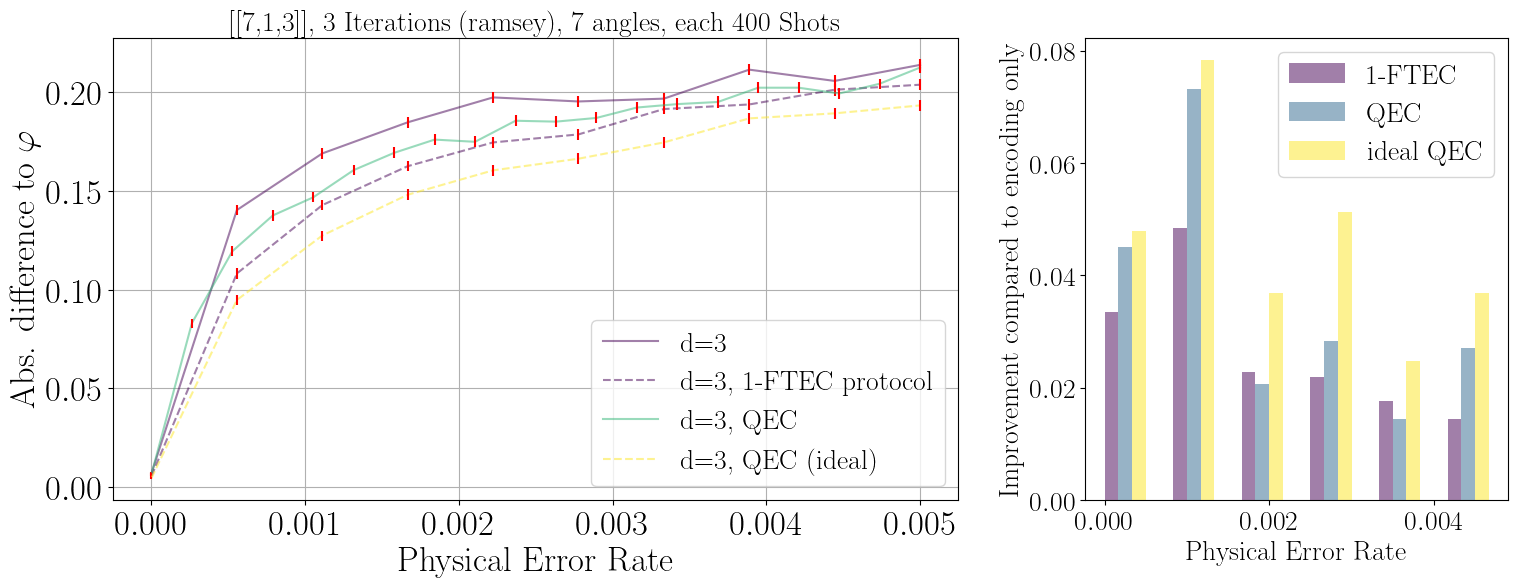

In [52]:
shots = 400

p1, y1, y_qec1, err1, err_qec1 = np.loadtxt("HPC/text/steane_protocol.txt", delimiter = ",")

p2, y2, y_qec2, err2, err_qec2 = np.loadtxt("HPC/text/steane_OG_ftqec+PS2.txt", delimiter = ",")

p3, y3, y_qec3, err3, err_qec3 = np.loadtxt("HPC/text/steane_OG_qec.txt", delimiter = ",")

# p4, y4, y_qec4, err4, err_qec4 = np.loadtxt("HPC/text/steane_depol_ftec.txt", delimiter = ",")

p5, y5, y_qec5, err5, err_qec5 = np.loadtxt("HPC/text/steane_idealqec.txt", delimiter = ",")


fig, (ax1,ax2) = plt.subplots(1,2,figsize=(18,6), gridspec_kw={"width_ratios": [2, 1]})

# try:
colors = plt.cm.viridis(np.linspace(0, 1, 7))
# except TypeError:
#     pass

ax1.plot(p1,y1, label="d=3", marker = "", linestyle = "-", markersize = 20, alpha = 0.5, color = colors[0])
ax1.errorbar(p1, y1, yerr=err1, ecolor="red", linestyle="")
ax1.plot(p1, y_qec1, label="d=3, 1-FTEC protocol", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[0])
ax1.errorbar(p1, y_qec1, yerr=err_qec1, ecolor="red", linestyle="")

# ax1.plot(p2, y_qec2, label="d=3, FT QEC+PS", marker = "", linestyle = "-", markersize = 20, alpha = 0.5, color = colors[2])
# ax1.errorbar(p2, y_qec2, yerr=err_qec2, ecolor="red", linestyle="")

ax1.plot(p3, y_qec3, label="d=3, QEC", marker = "", linestyle = "-", markersize = 20, alpha = 0.5, color = colors[4])
ax1.errorbar(p3, y_qec3, yerr=err_qec3, ecolor="red", linestyle="")

# ax1.plot(p4, y4, label="d=3 (depol.)", marker = "", linestyle = "-", markersize = 20, alpha = 0.5, color = colors[5])
# ax1.errorbar(p4, y4, yerr=err4, ecolor="red", linestyle="")

# ax1.plot(p4, y_qec4, label="d=3, 1-FTEC (depol.)", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[5])
# ax1.errorbar(p4, y_qec4, yerr=err_qec4, ecolor="red", linestyle="")

ax1.plot(p5, y_qec5, label="d=3, QEC (ideal)", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[6])
ax1.errorbar(p5, y_qec5, yerr=err_qec5, ecolor="red", linestyle="")

ax1.set_title(r"[[7,1,3]], 3 Iterations (ramsey), 7 angles, each {} Shots".format(int(shots)), fontsize=20)
ax1.set_xlabel("Physical Error Rate", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
ax1.legend(fontsize=20)# ax1.legend(fontsize=20)


x_hist = np.asarray(p1)

ftec_hist = -(np.asarray(y_qec1) - np.asarray(y1))
# qec_hist = -(np.asarray(y_qec3) - np.asarray(y1))
qec_ideal_hist  = -(np.asarray(y_qec5) - np.asarray(y1))

# Use the same bin edges for all histograms
bins = np.histogram_bin_edges(x_hist, bins=6)
bin_width = bins[1] - bins[0]

# Calculate weighted histogram values
ftec_counts, _ = np.histogram(x_hist, bins=bins, weights=ftec_hist)
qec_counts, _ = np.histogram(x_hist, bins=bins, weights=qec_hist)
qec_ideal_counts, _ = np.histogram(x_hist, bins=bins, weights=qec_ideal_hist)

# Four bars side-by-side within each bin
bar_width = bin_width / 5
x = bins[:-1]

ax2.bar(
    x,
    ftec_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[0],
    label="1-FTEC"
)

ax2.bar(
    x + bar_width,
    qec_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[2],
    label="QEC"
)

ax2.bar(
    x + 2 * bar_width,
    qec_ideal_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[6],
    label="ideal QEC"
)



ax2.legend(fontsize=20)

ax2.tick_params(axis='both', which='major', labelsize=20)
ax2.set_xlabel("Physical Error Rate", fontsize=20)
ax2.set_ylabel(r"Improvement compared to encoding only", fontsize=20)


#plt.tight_layout()
# plt.savefig("14.png", bbox_inches="tight" ,dpi=200)
plt.show()

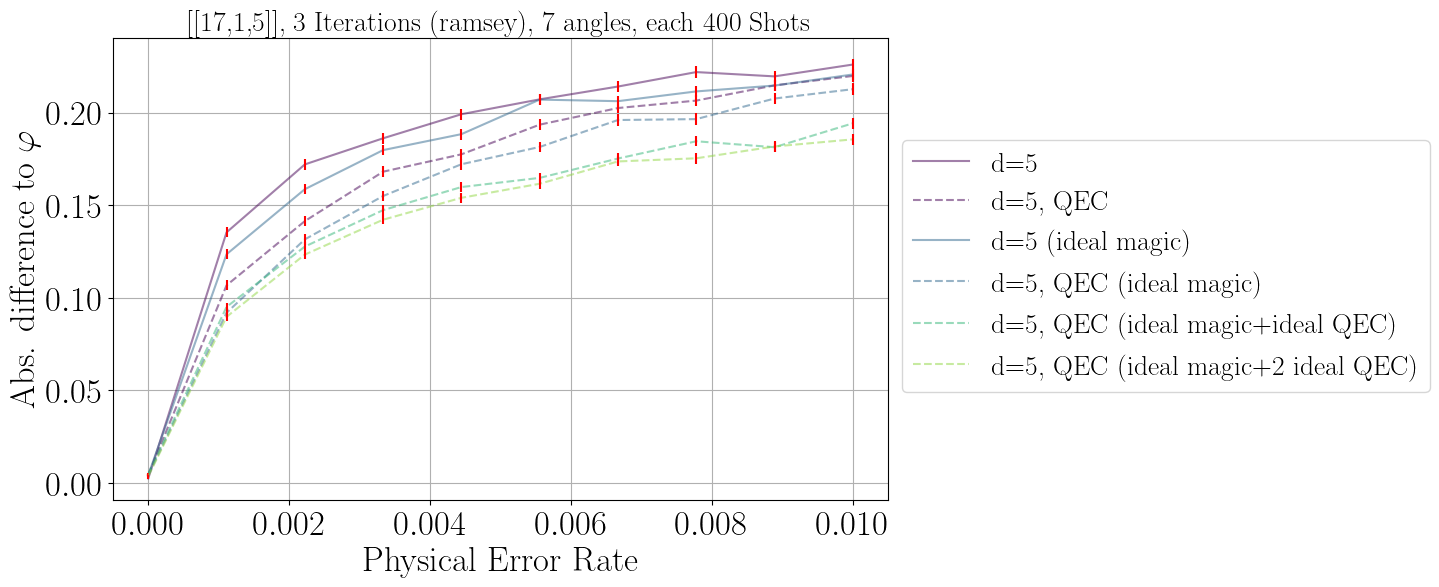

In [6]:
shots = 400

p1, y1, y_qec1, err1, err_qec1 = np.loadtxt("HPC/text/d5_steane.txt", delimiter = ",")
p2, y2, y_qec2, err2, err_qec2 = np.loadtxt("HPC/text/d5_steane_idealmagic.txt", delimiter = ",")
p3, y3, y_qec3, err3, err_qec3 = np.loadtxt("HPC/text/d5_steane_idealmagic+qec.txt", delimiter = ",")
p4, y4, y_qec4, err4, err_qec4 = np.loadtxt("HPC/text/d5_steane_idealmagic+2qec.txt", delimiter = ",")
p5, y5, y_qec5, err5, err_qec5 = np.loadtxt("HPC/text/d5_steane_2qec.txt", delimiter = ",")

fig, ax1 = plt.subplots(figsize=(10,6))

# try:
colors = plt.cm.viridis(np.linspace(0, 1, 7))
# except TypeError:
#     pass

ax1.plot(p1,y1, label="d=5", marker = "", linestyle = "-", markersize = 20, alpha = 0.5, color = colors[0])
ax1.errorbar(p1, y1, yerr=err1, ecolor="red", linestyle="")
ax1.plot(p1, y_qec1, label="d=5, QEC", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[0])
ax1.errorbar(p1, y_qec1, yerr=err_qec1, ecolor="red", linestyle="")

ax1.plot(p2,y2, label="d=5 (ideal magic)", marker = "", linestyle = "-", markersize = 20, alpha = 0.5, color = colors[2])
ax1.errorbar(p2, y2, yerr=err2, ecolor="red", linestyle="")
ax1.plot(p2, y_qec2, label="d=5, QEC (ideal magic)", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[2])
ax1.errorbar(p2, y_qec2, yerr=err_qec2, ecolor="red", linestyle="")

ax1.plot(p3, y_qec3, label="d=5, QEC (ideal magic+ideal QEC)", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[4])
ax1.errorbar(p3, y_qec3, yerr=err_qec3, ecolor="red", linestyle="")

ax1.plot(p4, y_qec4, label="d=5, QEC (ideal magic+2 ideal QEC)", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[5])
ax1.errorbar(p4, y_qec4, yerr=err_qec4, ecolor="red", linestyle="")

# ax1.plot(p5, y_qec5, label="d=5, 2 QEC", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color = colors[6])
# ax1.errorbar(p5, y_qec5, yerr=err_qec5, ecolor="red", linestyle="")

ax1.set_title(r"[[17,1,5]], 3 Iterations (ramsey), 7 angles, each {} Shots".format(int(shots)), fontsize=20)
ax1.set_xlabel("Physical Error Rate", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)


#plt.tight_layout()
# plt.savefig("14.png", bbox_inches="tight" ,dpi=200)
plt.show()

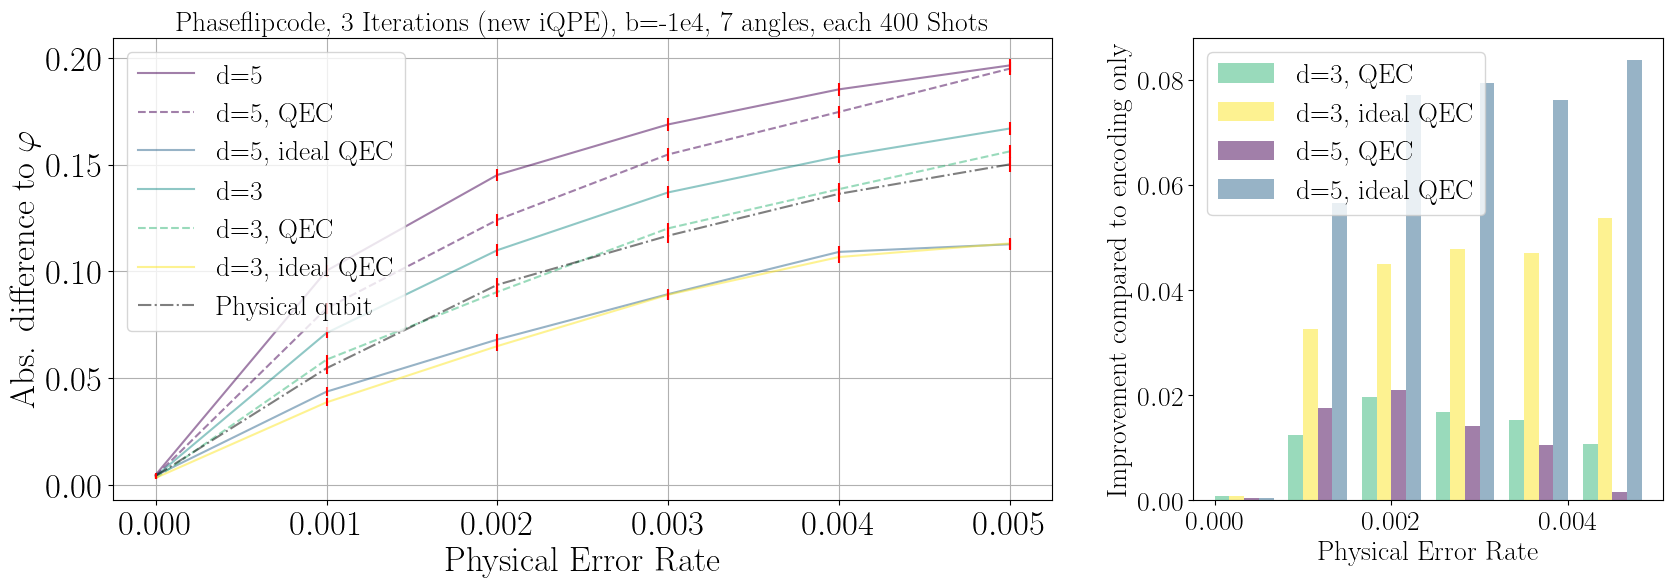

In [65]:
shots = 400

p0, y0, err0 = np.loadtxt("HPC/text/physicalq_smaller.txt", delimiter = ",")

p, y, y_qec, err, err_qec = np.loadtxt("HPC/text/d5_Repcodez_ramsey.txt", delimiter = ",")
p1, y1, y_qec1, err1, err_qec1 = np.loadtxt("HPC/text/d3_Repcodez_ramsey.txt", delimiter = ",")
p2, y2, y_qec2, err2, err_qec2 = np.loadtxt("HPC/text/d3_Repcodez_ramsey_ideal.txt", delimiter = ",")
p3, y3, y_qec3, err3, err_qec3 = np.loadtxt("HPC/text/d5_Repcodez_ramsey_ideal.txt", delimiter = ",")
# p4, y4, y_qec4, err4, err_qec4 = np.loadtxt("HPC/text/d5_Repcodez_ramsey_block.txt", delimiter = ",")

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(20,6), gridspec_kw={"width_ratios": [2, 1]})

colors = plt.cm.viridis(np.linspace(0, 1, 7))


############## d=5 Phaeflipcode ####################

ax1.plot(p,y, label="d=5", marker = "",markersize = 20, alpha = 0.5, color=colors[0])
ax1.errorbar(p, y, yerr=err, ecolor="red", linestyle="")

ax1.plot(p, y_qec, label="d=5, QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="--",color=colors[0])
ax1.errorbar(p, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(p3, y_qec3, label="d=5, ideal QEC", marker = "",markersize = 20, alpha = 0.5, color=colors[2])
ax1.errorbar(p3, y_qec3, yerr=err_qec3, ecolor="red", linestyle="")

# ax1.plot(p4, y_qec4, label="d=5, block QEC", marker = "",markersize = 20, alpha = 0.5)
# ax1.errorbar(p4, y_qec4, yerr=err_qec4, ecolor="red", linestyle="")
############## d=3 Phaeflipcode ####################

ax1.plot(p1,y1, label="d=3", marker = "", markersize = 20, alpha = 0.5, color=colors[3])
ax1.errorbar(p1, y1, yerr=err1, ecolor="red", linestyle="")

ax1.plot(p1, y_qec1, label="d=3, QEC", marker = "", linestyle = "--", markersize = 20, alpha = 0.5, color=colors[4])
ax1.errorbar(p1, y_qec1, yerr=err_qec1, ecolor="red", linestyle="")

ax1.plot(p2, y_qec2, label="d=3, ideal QEC", marker = "", markersize = 20, alpha = 0.5, color=colors[6])
ax1.errorbar(p2, y_qec2, yerr=err_qec2, ecolor="red", linestyle="")

############## Physical Qubit ####################

ax1.plot(p0, y0, label="Physical qubit", marker = "",markersize = 20, alpha = 0.5, linestyle="-.", color="black")
ax1.errorbar(p0, y0, yerr=err0, ecolor="red", linestyle="")

#################### ####################

ax1.set_title(r"Phaseflipcode, 3 Iterations (new iQPE), b=-1e4, 7 angles, each {} Shots".format(int(shots)), fontsize=20)
ax1.set_xlabel("Physical Error Rate", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
ax1.legend(fontsize=20)# ax1.legend(fontsize=20)



x_hist = np.asarray(p1)

d3_qec_hist = -(np.asarray(y_qec1) - np.asarray(y1))
d3_qec_ideal_hist = -(np.asarray(y_qec2) - np.asarray(y1))
d5_qec_hist  = -(np.asarray(y_qec) - np.asarray(y))
d5_qec_ideal_hist = -(np.asarray(y_qec3) - np.asarray(y))

# Use the same bin edges for all histograms
bins = np.histogram_bin_edges(x_hist, bins=6)
bin_width = bins[1] - bins[0]

# Calculate weighted histogram values
d3_qec_counts, _ = np.histogram(x_hist, bins=bins, weights=d3_qec_hist)
d3_qec_ideal_counts, _ = np.histogram(x_hist, bins=bins, weights=d3_qec_ideal_hist)
d5_qec_counts, _ = np.histogram(x_hist, bins=bins, weights=d5_qec_hist)
d5_qec_ideal_counts, _ = np.histogram(x_hist, bins=bins, weights=d5_qec_ideal_hist)

# Four bars side-by-side within each bin
bar_width = bin_width / 5
x = bins[:-1]

ax2.bar(
    x,
    d3_qec_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[4],
    label="d=3, QEC"
)

ax2.bar(
    x + bar_width,
    d3_qec_ideal_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[6],
    label="d=3, ideal QEC"
)

ax2.bar(
    x + 2 * bar_width,
    d5_qec_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[0],
    label="d=5, QEC"
)

ax2.bar(
    x + 3 * bar_width,
    d5_qec_ideal_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[2],
    label="d=5, ideal QEC"
)


ax2.legend(fontsize=20)

ax2.tick_params(axis='both', which='major', labelsize=20)
ax2.set_xlabel("Physical Error Rate", fontsize=20)
ax2.set_ylabel(r"Improvement compared to encoding only", fontsize=20)



#plt.tight_layout()
# plt.savefig("14.png", bbox_inches="tight" ,dpi=200)
plt.show()

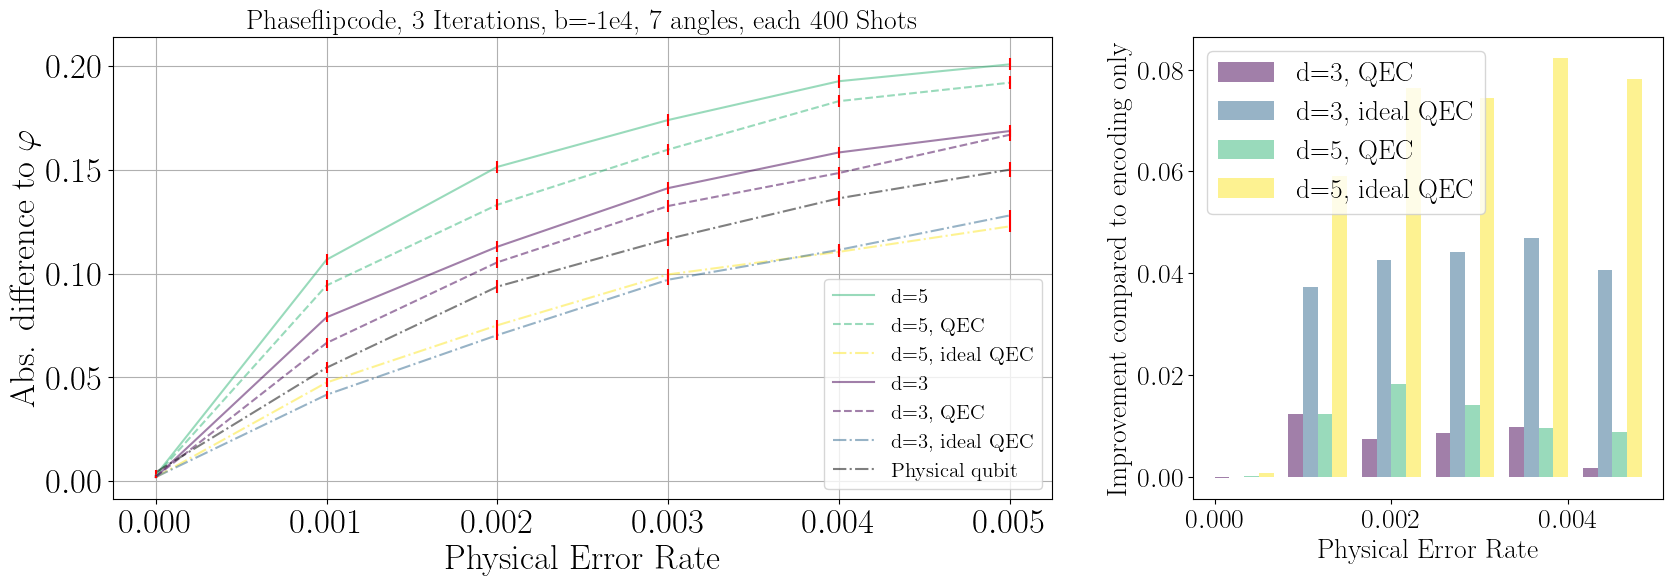

In [42]:
shots = 400

p0, y0, err0 = np.loadtxt("HPC/text/physicalq_smaller.txt", delimiter = ",")

p, y, y_qec, err, err_qec = np.loadtxt("HPC/text/d5_Repcodez_smaller.txt", delimiter = ",")

p1, y1, y_qec1, err1, err_qec1 = np.loadtxt("HPC/text/d3_Repcodez_smaller.txt", delimiter = ",")

p2, y2, y_qec2, err2, err_qec2 = np.loadtxt("HPC/text/d3_Repcodez_smaller_ideal.txt", delimiter = ",")

p3, y3, y_qec3, err3, err_qec3 = np.loadtxt("HPC/text/d3_Repcodez_smaller_block.txt", delimiter = ",")

p4, y4, y_qec4, err4, err_qec4 = np.loadtxt("HPC/text/d5_Repcodez_smaller_ideal.txt", delimiter = ",")

p5, y5, y_qec5, err5, err_qec5 = np.loadtxt("HPC/text/d5_Repcodez_block_-1_.txt", delimiter = ",")

p6, y6, y_qec6, err6, err_qec6 = np.loadtxt("HPC/text/d5_Repcodez_block_-2_.txt", delimiter = ",")

# fig, ax1 = plt.subplots(figsize=(10,6))

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(20,6), gridspec_kw={"width_ratios": [2, 1]})

colors = plt.cm.viridis(np.linspace(0, 1, 7))

################ d=5 Phaselfipcode #####################
ax1.plot(p,y, label="d=5", marker = "",markersize = 20, alpha = 0.5, color=colors[4])
ax1.errorbar(p, y, yerr=err, ecolor="red", linestyle="")

ax1.plot(p,y_qec, label="d=5, QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="--", color=colors[4])
ax1.errorbar(p, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(p4,y_qec4, label="d=5, ideal QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="-.", color=colors[6])
ax1.errorbar(p4, y_qec4, yerr=err_qec4, ecolor="red", linestyle="")

################## d=3 Phaseflipcode #####################
ax1.plot(p1,y1, label="d=3", marker = "",markersize = 20, alpha = 0.5, linestyle="-", color=colors[0])
ax1.errorbar(p1, y1, yerr=err1, ecolor="red", linestyle="")

ax1.plot(p1,y_qec1, label="d=3, QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="--", color=colors[0])
ax1.errorbar(p1, y_qec1, yerr=err_qec1, ecolor="red", linestyle="")

ax1.plot(p2, y_qec2, label="d=3, ideal QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="-.", color=colors[2])
ax1.errorbar(p2, y_qec2, yerr=err_qec2, ecolor="red", linestyle="")

# ax1.plot(p3, y_qec3, label="d=3, block QEC", marker = "", markersize = 20, alpha = 0.5, linestyle="--")
# ax1.errorbar(p3, y_qec3, yerr=err_qec3, ecolor="red", linestyle="")

################d=5 QEC block#####################

# ax1.plot(p5, y_qec5, label="d=5, QEC (block)", marker = ".",markersize = 20, alpha = 0.5, linestyle="")
# ax1.errorbar(p5, y_qec5, yerr=err_qec5, ecolor="red", linestyle="")

# ax1.plot(p6, y_qec6, label="d=5, QEC (block)", marker = ".",markersize = 20, alpha = 0.5, linestyle="")
# ax1.errorbar(p6, y_qec6, yerr=err_qec6, ecolor="red", linestyle="")

############## Physical Qubit ####################

ax1.plot(p0, y0, label="Physical qubit", marker = "",markersize = 20, alpha = 0.5, linestyle="-.", color="black")
ax1.errorbar(p0, y0, yerr=err0, ecolor="red", linestyle="")

ax1.legend(fontsize=15)

#################### ####################

x_hist = np.asarray(p1)

d3_qec_hist = -(np.asarray(y_qec1) - np.asarray(y1))
d3_qec_ideal_hist = -(np.asarray(y_qec2) - np.asarray(y1))
d5_qec_hist  = -(np.asarray(y_qec) - np.asarray(y))
d5_qec_ideal_hist = -(np.asarray(y_qec4) - np.asarray(y))

# Use the same bin edges for all histograms
bins = np.histogram_bin_edges(x_hist, bins=6)
bin_width = bins[1] - bins[0]

# Calculate weighted histogram values
d3_qec_counts, _ = np.histogram(x_hist, bins=bins, weights=d3_qec_hist)
d3_qec_ideal_counts, _ = np.histogram(x_hist, bins=bins, weights=d3_qec_ideal_hist)
d5_qec_counts, _ = np.histogram(x_hist, bins=bins, weights=d5_qec_hist)
d5_qec_ideal_counts, _ = np.histogram(x_hist, bins=bins, weights=d5_qec_ideal_hist)

# Four bars side-by-side within each bin
bar_width = bin_width / 5
x = bins[:-1]

ax2.bar(
    x,
    d3_qec_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[0],
    label="d=3, QEC"
)

ax2.bar(
    x + bar_width,
    d3_qec_ideal_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[2],
    label="d=3, ideal QEC"
)

ax2.bar(
    x + 2 * bar_width,
    d5_qec_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[4],
    label="d=5, QEC"
)

ax2.bar(
    x + 3 * bar_width,
    d5_qec_ideal_counts,
    width=bar_width,
    align="edge",
    alpha=0.5,
    color=colors[6],
    label="d=5, ideal QEC"
)


ax2.legend(fontsize=20)

ax2.tick_params(axis='both', which='major', labelsize=20)
ax2.set_xlabel("Physical Error Rate", fontsize=20)
ax2.set_ylabel(r"Improvement compared to encoding only", fontsize=20)


ax1.set_title(r"Phaseflipcode, 3 Iterations, b=-1e4, 7 angles, each {} Shots".format(int(shots)), fontsize=20)
ax1.set_xlabel("Physical Error Rate", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
# ax1.set_xscale("log")
# fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)


#plt.tight_layout()
# plt.savefig("14.png", bbox_inches="tight" ,dpi=200)
plt.show()

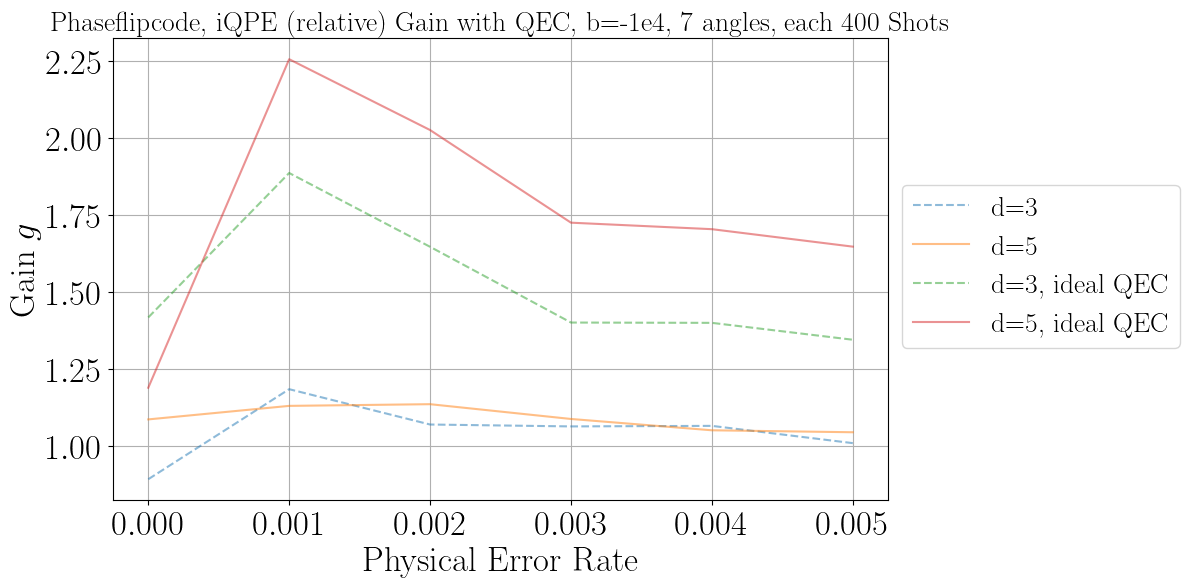

In [ ]:
#Based on previous plot: Look at performance improvement with QEC compared to no QEC at all

#relative gain with QEC: g = log2(y_noQEC/y_QEC)
type, g_d3, g_d5, g_d3_ideal, g_d5_ideal = "relative", [i/j for i,j in zip(y1,y_qec1)], [i/j for i,j in zip(y,y_qec)], [i/j for i,j in zip(y2,y_qec2)], [i/j for i,j in zip(y4,y_qec4)]

#absolute gain with QEC: g = (y_noQEC/y_QEC)/0.25
# type, g_d3, g_d5, g_d3_ideal, g_d5_ideal = "absolute", [((i-j)/0.25) for i,j in zip(y1,y_qec1)], [((i-j)/0.25) for i,j in zip(y,y_qec)], [((i-j)/0.25) for i,j in zip(y2,y_qec2)], [((i-j)/0.25) for i,j in zip(y4,y_qec4)]

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(p0, g_d3, label="d=3", marker = "",markersize = 20, alpha = 0.5, linestyle="--")
ax1.plot(p0, g_d5, label="d=5", marker = "",markersize = 20, alpha = 0.5)
ax1.plot(p0, g_d3_ideal, label="d=3, ideal QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="--")
ax1.plot(p0, g_d5_ideal, label="d=5, ideal QEC", marker = "",markersize = 20, alpha = 0.5)


ax1.set_title(r"Phaseflipcode, iQPE ({}) Gain with QEC, b=-1e4, 7 angles, each {} Shots".format(type, int(shots)), fontsize=20)
ax1.set_xlabel("Physical Error Rate", fontsize=25)
ax1.set_ylabel(r"Gain $g$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
# ax1.set_xscale("log")
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)

#plt.tight_layout()
# plt.savefig("14.png", bbox_inches="tight" ,dpi=200)
plt.show()

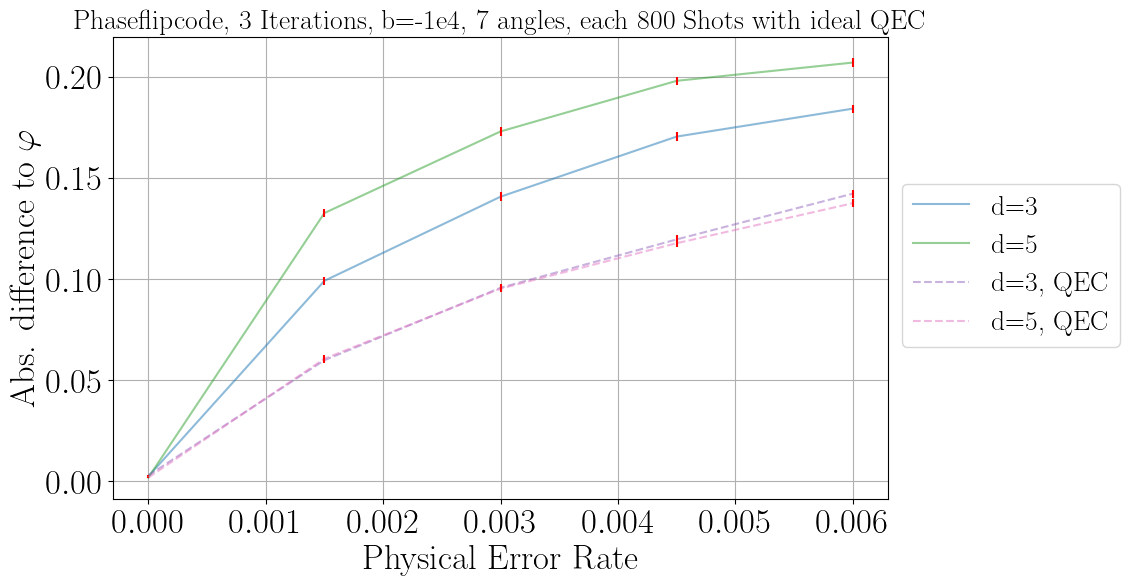

In [13]:
# 800 Shots hier!
# p, y, y_qec, err, err_qec = np.loadtxt("HPC/text/d5_Repcodez_smaller.txt", delimiter = ",")

shots = 800

p1, y1, y_qec1, err1, err_qec1 = np.loadtxt("HPC/text/d3_Repcodez_large_ideal.txt", delimiter = ",")
p2, y2, y_qec2, err2, err_qec2 = np.loadtxt("HPC/text/d5_Repcodez_large_ideal.txt", delimiter = ",")                #identical to d5_Repcodez_large_ideal.txt, but with  400 Shots instead of 800 and different error values


fig, ax1 = plt.subplots(figsize=(10,6))

try:
    colors = plt.cm.viridis(np.linspace(0, 1, len(10)))
except TypeError:
    pass
################ no QEC #####################

ax1.plot(p1,y1, label="d=3", marker = "",markersize = 20, alpha = 0.5)
ax1.errorbar(p1, y1, yerr=err1, ecolor="red", linestyle="")

ax1.plot(p2,y2, label="d=5", marker = "",markersize = 20, alpha = 0.5)
ax1.errorbar(p2, y2, yerr=err2, ecolor="red", linestyle="")

################## ideal QEC #####################

ax1.plot(p1,y_qec1, label="d=3, QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="--")
ax1.errorbar(p1, y_qec1, yerr=err_qec1, ecolor="red", linestyle="")

ax1.plot(p2,y_qec2, label="d=5, QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="--")
ax1.errorbar(p2, y_qec2, yerr=err_qec2, ecolor="red", linestyle="")


ax1.set_title(r"Phaseflipcode, 3 Iterations, b=-1e4, 7 angles, each {} Shots with ideal QEC".format(int(shots)), fontsize=20)
ax1.set_xlabel("Physical Error Rate", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
# ax1.set_xscale("log")
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)


#plt.tight_layout()
# plt.savefig("14.png", bbox_inches="tight" ,dpi=200)
plt.show()

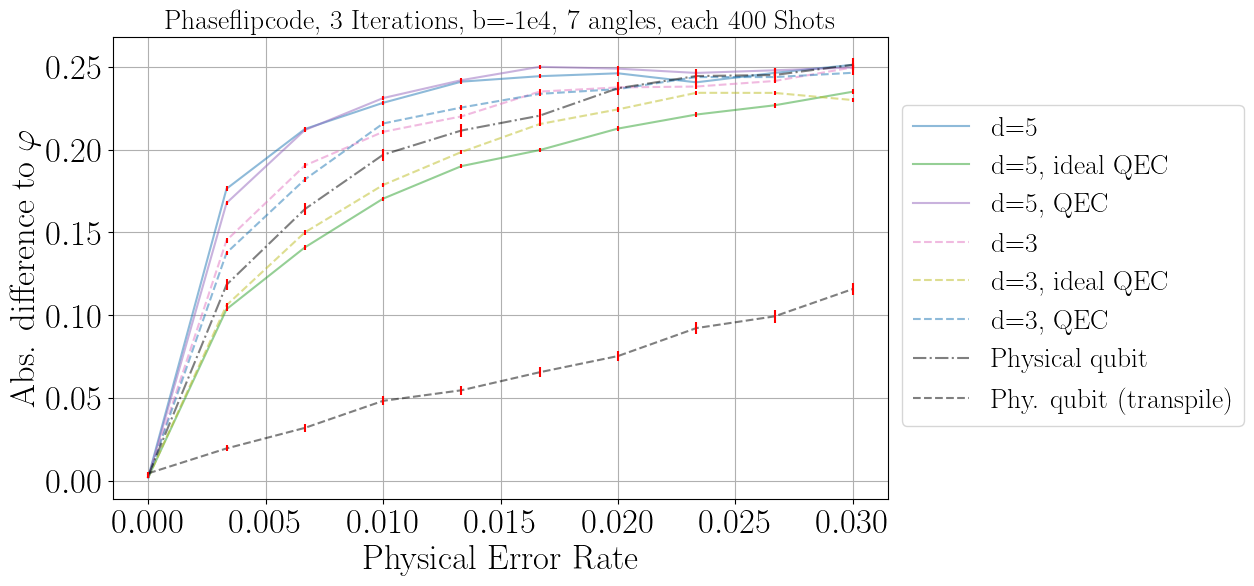

In [19]:
shots = 400
p, y, y_qec, err, err_qec = np.loadtxt("HPC/text/d5_Repcodez_ideal.txt", delimiter = ",")               #NEU MACHEN
y, y_qec = [i*(15/7) for i in y], [i*(15/7) for i in y_qec]

p1, y1, y_qec1, err1, err_qec1 = np.loadtxt("HPC/text/d3_Repcodez_ideal.txt", delimiter = ",")                  #NEU MACHEN
y1, y_qec1 = [i*(15/7) for i in y1], [i*(15/7) for i in y_qec1]

p2, y2, y_qec2, err2, err_qec2 = np.loadtxt("HPC/text/d3_Repcodez.txt", delimiter = ",")                        #NEU MACHEN
y2, y_qec2 = [i*(15/7) for i in y2], [i*(15/7) for i in y_qec2]

p3, y3, err3 = np.loadtxt("HPC/text/physicalq.txt", delimiter = ",")

p3_t, y3_t, err3_t = np.loadtxt("HPC/text/physicalq_transpile.txt", delimiter = ",")

p4, y4, y_qec4, err4, err_qec4 = np.loadtxt("HPC/text/d5_Repcodez.txt", delimiter = ",")                    #NEU MACHEN

p5, y5, y_qec5, err5, err_qec5 = np.loadtxt("HPC/text/d5_Repcodez_block_0_.txt", delimiter = ",")               #NEU MACHEN

# err, err_qec = [i/np.sqrt(shots) for i in err], [i/np.sqrt(shots) for i in err_qec]

fig, ax1 = plt.subplots(figsize=(10,6))

colors = plt.cm.viridis(np.linspace(0, 1, len(p)))

ax1.plot(p,y, label="d=5", marker = "",markersize = 20, alpha = 0.5)
ax1.errorbar(p, y, yerr=err, ecolor="red", linestyle="")

ax1.plot(p,y_qec, label="d=5, ideal QEC", marker = "",markersize = 20, alpha = 0.5)
ax1.errorbar(p, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(p4,y_qec4, label="d=5, QEC", marker = "",markersize = 20, alpha = 0.5)
ax1.errorbar(p4, y_qec4, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(p1,y1, label="d=3", marker = "",markersize = 20, alpha = 0.5, linestyle="--")
ax1.errorbar(p1, y1, yerr=err, ecolor="red", linestyle="")

ax1.plot(p1,y_qec1, label="d=3, ideal QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="--")
ax1.errorbar(p1, y_qec1, yerr=err_qec, ecolor="red", linestyle="")

# ax1.plot(p2,y2, label="d=3, No QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="--")
# ax1.errorbar(p2, y_qec2, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(p2,y_qec2, label="d=3, QEC", marker = "",markersize = 20, alpha = 0.5, linestyle="--")
ax1.errorbar(p2, y_qec2, yerr=err_qec, ecolor="red", linestyle="")

ax1.plot(p3, y3, label="Physical qubit", marker = "",markersize = 20, alpha = 0.5, linestyle="-.", color="black")
ax1.errorbar(p3, y3, yerr=err3, ecolor="red", linestyle="")

ax1.plot(p3_t, y3_t, label="Phy. qubit (transpile)", marker = "",markersize = 20, alpha = 0.5, linestyle="--", color="black")
ax1.errorbar(p3_t, y3_t, yerr=err3_t, ecolor="red", linestyle="")

#################### QEC 5 Block + MWPM decoder ####################

# ax1.plot(p5, y5, label="d=5", marker = ".",markersize = 20, alpha = 0.5)
# ax1.errorbar(p5, y5, yerr=err5, ecolor="red", linestyle="")

# ax1.plot(p5, y_qec5, label="d=5, QEC (block)", marker = ".",markersize = 20, alpha = 0.5)
# ax1.errorbar(p5, y_qec5, yerr=err_qec5, ecolor="red", linestyle="")

#################### ####################

ax1.set_title(r"Phaseflipcode, 3 Iterations, b=-1e4, 7 angles, each {} Shots".format(int(shots)), fontsize=20)
ax1.set_xlabel("Physical Error Rate", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)


#plt.tight_layout()
# plt.savefig("14.png", bbox_inches="tight" ,dpi=200)
plt.show()

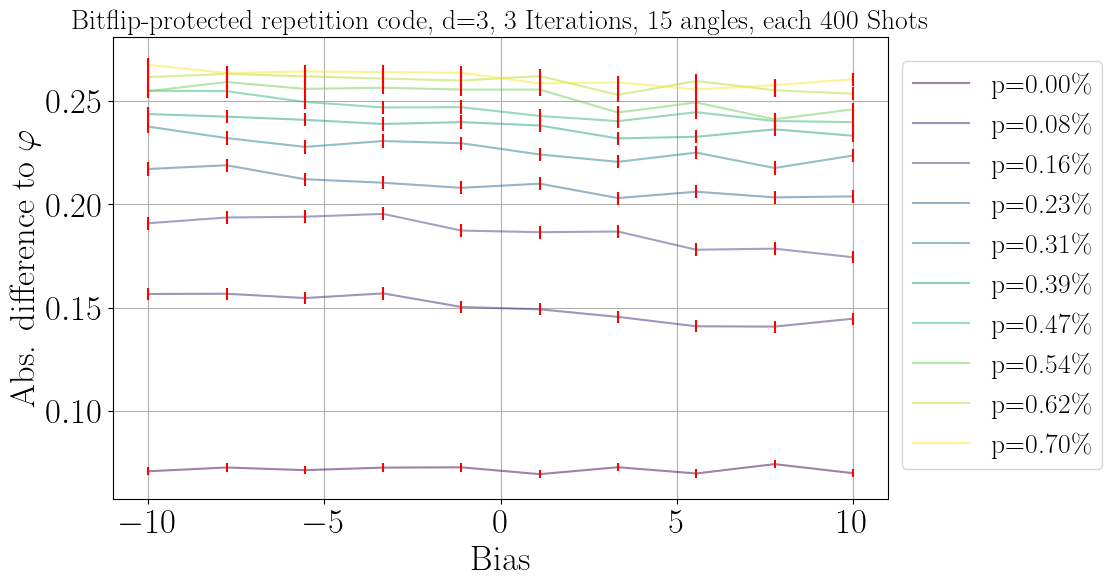

In [2]:
shots = 400
data = np.load("HPC/text/Repcode_d3.npy")

p = np.linspace(0,0.007,10)

fig, ax1 = plt.subplots(figsize=(10,6))

colors = plt.cm.viridis(np.linspace(0, 1, len(p)))

for i,layer in enumerate(data):
    bias, y, y_qec, err, err_qec = layer[0], layer[1], layer[2], layer[3], layer[4]
    ax1.plot(bias, y, label=r"p={:.2f}\%".format(100*p[i]), marker = "",markersize = 20, alpha = 0.5, color=colors[i])
    #ax1.plot(bias, y_qec, label=r"p={:.2f}\%, QEC".format(100*p[i]), marker = "",markersize = 20, alpha = 0.5, color=colors[i], linestyle=":")
    ax1.errorbar(bias, y, yerr=err, ecolor="red", linestyle="")
   #ax1.errorbar(bias, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.set_title(r"Bitflip-protected repetition code, d=3, 3 Iterations, 15 angles, each {} Shots".format(int(shots)), fontsize=20)
ax1.set_xlabel("Bias", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)


#plt.tight_layout()
plt.savefig("repcode_d9_bias.png", bbox_inches="tight" ,dpi=200)
plt.show()

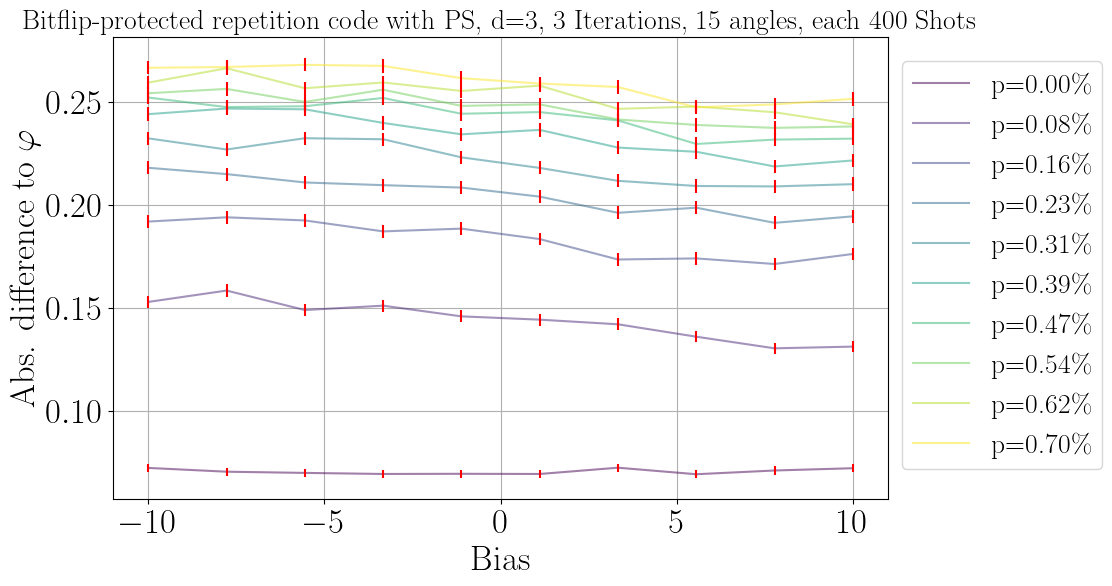

In [3]:
shots = 400
data = np.load("HPC/text/Repcode_d3_post.npy")

p = np.linspace(0,0.007,10)

fig, ax1 = plt.subplots(figsize=(10,6))

colors = plt.cm.viridis(np.linspace(0, 1, len(p)))

for i,layer in enumerate(data):
    bias, y, y_qec, err, err_qec = layer[0], layer[1], layer[2], layer[3], layer[4]
    ax1.plot(bias, y, label=r"p={:.2f}\%".format(100*p[i]), marker = "",markersize = 20, alpha = 0.5, color=colors[i])
    #ax1.plot(bias, y_qec, label=r"p={:.2f}\%, QEC".format(100*p[i]), marker = "",markersize = 20, alpha = 0.5, color=colors[i], linestyle=":")
    ax1.errorbar(bias, y, yerr=err, ecolor="red", linestyle="")
    #ax1.errorbar(bias, y_qec, yerr=err_qec, ecolor="red", linestyle="")

ax1.set_title(r"Bitflip-protected repetition code with PS, d=3, 3 Iterations, 15 angles, each {} Shots".format(int(shots)), fontsize=20)
ax1.set_xlabel("Bias", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)


#plt.tight_layout()
plt.savefig("repcode_d9_bias.png", bbox_inches="tight" ,dpi=200)
plt.show()

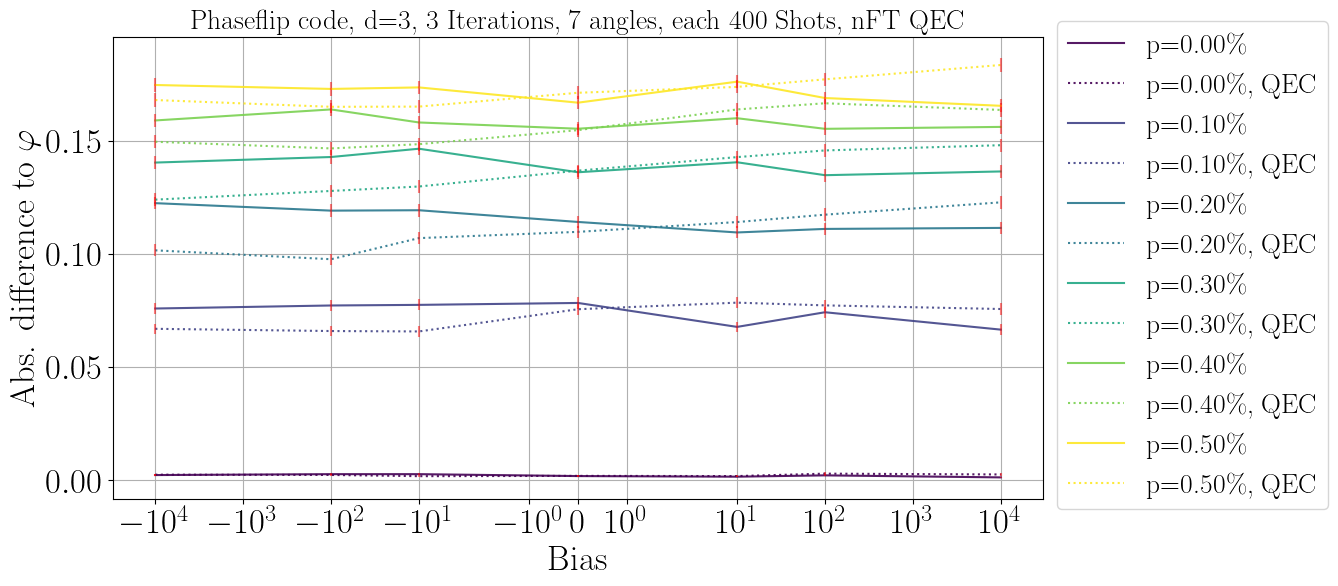

In [9]:
shots, angles = 400, 7
# data, p = np.load("HPC/text/Repcodez_d3_qec.npy"), np.linspace(0.00,0.01,10)                     #np.linspace(0.00,0.01,10)          ; alte lange circuits mit HTHTdgH..., ohne t_x, s_x, ...
# data, p = np.load("HPC/text/Repcodez_d3_idealqec.npy"), np.linspace(0.00,0.005,5)              #np.linspace(0.00,0.005,5)              ; alte lange circuits mit HTHTdgH..., ohne t_x, s_x, ...
# data, p = np.load("HPC/text/Repcodez_d3_idealqec_new.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)
# data, p = np.load("HPC/text/Repcodez_d3_ftqec.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)
# data, p = np.load("HPC/text/Repcodez_d3_nftqec.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)

# Ab hier: neue Metrik, die abs. difference to phi kann nur maximal 0.5 betragen, außerdem wird für std der avg für jeden Shot an sich (avg über 15 Winkel genommen) und dann über die 400 Shots die std berechnet
# data, p = np.load("HPC/text/Phasecode_d3_idealqec.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)
# data, p = np.load("HPC/text/Phasecode_d3_nftqec.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)
#data, p = np.load("HPC/text/Phasecode_d3_ftqec.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)

data, p = np.load("HPC/text/Phasecode_d3_exactangles_nftqec.npy"), np.linspace(0.00,0.005,6)             #np.linspace(0.00,0.005,6)


fig, ax1 = plt.subplots(figsize=(12,6))

colors = plt.cm.viridis(np.linspace(0, 1, len(p)))

for i,layer in enumerate(data):
    bias, y, y_qec, err, err_qec = layer[0], layer[1], layer[2], layer[3], layer[4]
    # err, err_qec = [i*np.sqrt(20) for i in err], [i*np.sqrt(20) for i in err_qec]
    ax1.plot(bias, y, label=r"p={:.2f}\%".format(100*p[i]), marker = "",markersize = 20, alpha = 0.9, color=colors[i])
    ax1.plot(bias, y_qec, label=r"p={:.2f}\%, QEC".format(100*p[i]), marker = "",markersize = 20, alpha = 0.9, color=colors[i], linestyle=":")
    ax1.errorbar(bias, y, yerr=err, ecolor="red", linestyle="", alpha=0.5)
    ax1.errorbar(bias, y_qec, yerr=err_qec, ecolor="red", linestyle="", alpha=0.5)

# for i,layer in enumerate(data_qec):
#     bias, y, err = layer[0], layer[1], layer[2]
#     ax1.plot(bias, y, label=r"p={:.2f}\%".format(100*p[i]), marker = "",markersize = 20, alpha = 0.5, color=colors[i], linestyle=":")
#     #ax1.plot(bias, y_qec, label=r"p={:.2f}\%, QEC".format(100*p[i]), marker = "",markersize = 20, alpha = 0.5, color=colors[i], linestyle=":")
#     ax1.errorbar(bias, y, yerr=err, ecolor="red", linestyle="")

ax1.set_title(r"Phaseflip code, d=3, 3 Iterations, {} angles, each {} Shots, nFT QEC".format(angles, int(shots)), fontsize=20)
ax1.set_xlabel("Bias", fontsize=25)
ax1.set_ylabel(r"Abs. difference to $\varphi$", fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.grid()
fig.legend(loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=20)# ax1.legend(fontsize=20)
plt.xscale("symlog")
# plt.yscale("log")

#caption="Every Toff_L has 3 QEC steps to ensure FT. In case of QEC, we include two QEC cycles during each H_L, one right at the beginning of H_L on the target qubit and one after preparing -_L on -_L."  #case of only idealqec! (not idealqec_new!)
# caption="In case of QEC, Toff_L has 3 QEC steps inside, else not. Otherwise, there are no difference between the circuits with or w/o QEC."
# wrapped_caption = textwrap.fill(caption, width=180)

# # Add caption
# fig.text(
#     0.65,
#     -0.09,
#     wrapped_caption,
#     ha='center',
#     va='bottom',
#     fontsize=12
# )


# plt.tight_layout()
# plt.savefig("figures/phasecode_d3_ftqec.png", bbox_inches="tight" ,dpi=200)
plt.show()